# 01. Exploratory Data Analysis - Real Estate Market Trends
**Real Estate Market Intelligence Dashboard**

This notebook performs comprehensive Exploratory Data Analysis (EDA) on the cleaned properties dataset to extract actionable insights for executives and investors. We analyze price distributions, regional variations, feature correlations, and formulate the **Investment Opportunity Score**.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot styling for a professional look
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

### 1. Load Cleaned Dataset

In [2]:
data_path = "../data/cleaned_properties.csv"
df = pd.read_csv(data_path)
print(f"Loaded dataset with {df.shape[0]} listings and {df.shape[1]} features.")
df.head()

Loaded dataset with 3491 listings and 17 features.


,Property_ID,Title,City,Locality,Property_Type,Price_USD,Area_SqFt,Bedrooms,Bathrooms,Year_Built,Listing_Date,Status,Demand_Score,Customer_Rating,Price_Per_SqFt,Property_Age,Investment_Score
0,PROP-10000,3 BHK Villa for sale in Manhattan,New York,Manhattan,Villa,5173316.59,2943.0,3,2,2017.0,2024-01-31,Active,10,4.6,1757.84,9.0,8.3
1,PROP-10001,Residential plot of 3547 sqft in Brooklyn,New York,Brooklyn,Plot,3892878.45,3547.0,0,0,1994.0,2024-12-10,Pending,2,4.2,1097.51,32.0,4.9
2,PROP-10002,3 BHK Apartment for sale in Loop,Chicago,Loop,Apartment,816513.13,2198.0,3,3,1944.0,2024-02-16,Pending,2,4.7,371.48,82.0,5.0
3,PROP-10003,2 BHK Apartment for sale in South Austin,Austin,South Austin,Apartment,690926.29,1593.0,2,1,1979.0,2025-10-17,Active,6,4.7,433.73,47.0,6.8
4,PROP-10004,Commercial Space / Office in Pacific Heights,San Francisco,Pacific Heights,Commercial,43066159.08,22064.0,0,9,1969.0,2024-09-09,Sold,5,4.5,1951.87,57.0,6.3


### 2. General Data Overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3491 entries, 0 to 3490
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Property_ID       3491 non-null   str    
 1   Title             3491 non-null   str    
 2   City              3491 non-null   str    
 3   Locality          3491 non-null   str    
 4   Property_Type     3491 non-null   str    
 5   Price_USD         3491 non-null   float64
 6   Area_SqFt         3491 non-null   float64
 7   Bedrooms          3491 non-null   int64  
 8   Bathrooms         3491 non-null   int64  
 9   Year_Built        3491 non-null   float64
 10  Listing_Date      3491 non-null   str    
 11  Status            3491 non-null   str    
 12  Demand_Score      3491 non-null   int64  
 13  Customer_Rating   3491 non-null   float64
 14  Price_Per_SqFt    3491 non-null   float64
 15  Property_Age      3491 non-null   float64
 16  Investment_Score  3491 non-null   float64
dtypes: flo

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Price_USD,3491.0,5.118134e+06,6.443622e+06,154831.43,1341912.220,2914925.62,6349039.650,55548716.42
Area_SqFt,3491.0,5.945134e+03,5.536685e+03,501.00,2074.500,4066.00,7602.000,24976.00
Bedrooms,3491.0,1.698367e+00,2.026853e+00,0.00,0.000,0.00,3.000,6.00
Bathrooms,3491.0,2.871384e+00,2.680357e+00,0.00,0.000,2.00,4.000,10.00
Year_Built,3491.0,1.988915e+03,2.069912e+01,1920.00,1983.000,1991.00,2000.000,2024.00
Demand_Score,3491.0,5.780006e+00,2.892092e+00,1.00,3.000,6.00,8.000,10.00
Customer_Rating,3491.0,4.115898e+00,5.576834e-01,3.00,3.700,4.20,4.600,5.00
Price_Per_SqFt,3491.0,8.550453e+02,5.123038e+02,68.78,436.235,655.28,1206.345,3419.76
Property_Age,3491.0,3.708450e+01,2.069912e+01,2.00,26.000,35.00,43.000,106.00
Investment_Score,3491.0,6.282211e+00,1.297377e+00,3.10,5.200,6.20,7.500,9.20


### 3. Price Analysis by City & Property Type

/var/folders/h0/tj8nz8m14mg2c5114wlv_3zh0000gq/T/ipykernel_11330/2725072945.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='City', y='Price_Per_SqFt', palette='viridis')


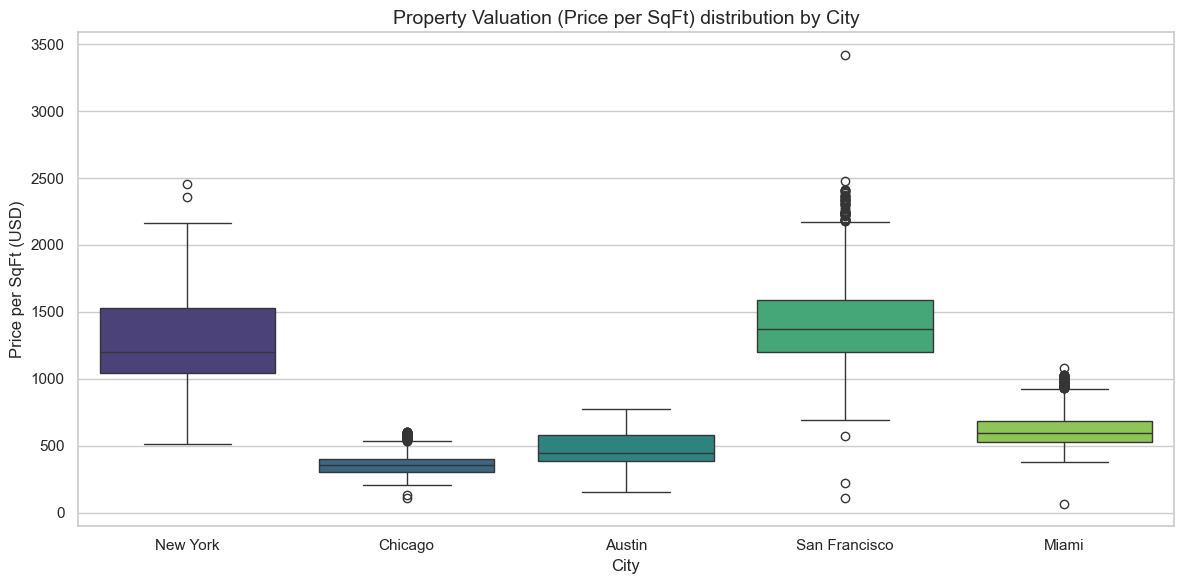

In [5]:
# Distribution of Price per SqFt across different Cities
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='City', y='Price_Per_SqFt', palette='viridis')
plt.title('Property Valuation (Price per SqFt) distribution by City')
plt.ylabel('Price per SqFt (USD)')
plt.xlabel('City')
plt.tight_layout()
os.makedirs('../screenshots', exist_ok=True)
plt.savefig('../screenshots/price_per_sqft_by_city.png', dpi=300)
plt.show()

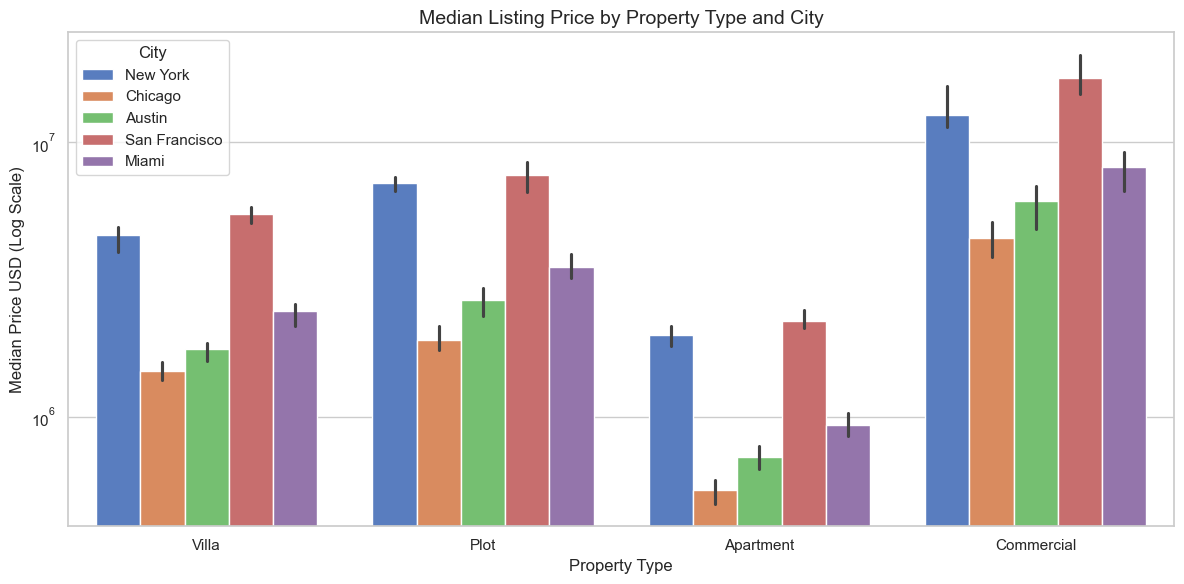

In [6]:
# Price distribution by Property Type
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='Property_Type', y='Price_USD', hue='City', estimator=np.median, palette='muted')
plt.title('Median Listing Price by Property Type and City')
plt.ylabel('Median Price USD (Log Scale)')
plt.yscale('log')
plt.xlabel('Property Type')
plt.tight_layout()
plt.savefig('../screenshots/median_price_by_type.png', dpi=300)
plt.show()

### 4. Correlation Analysis

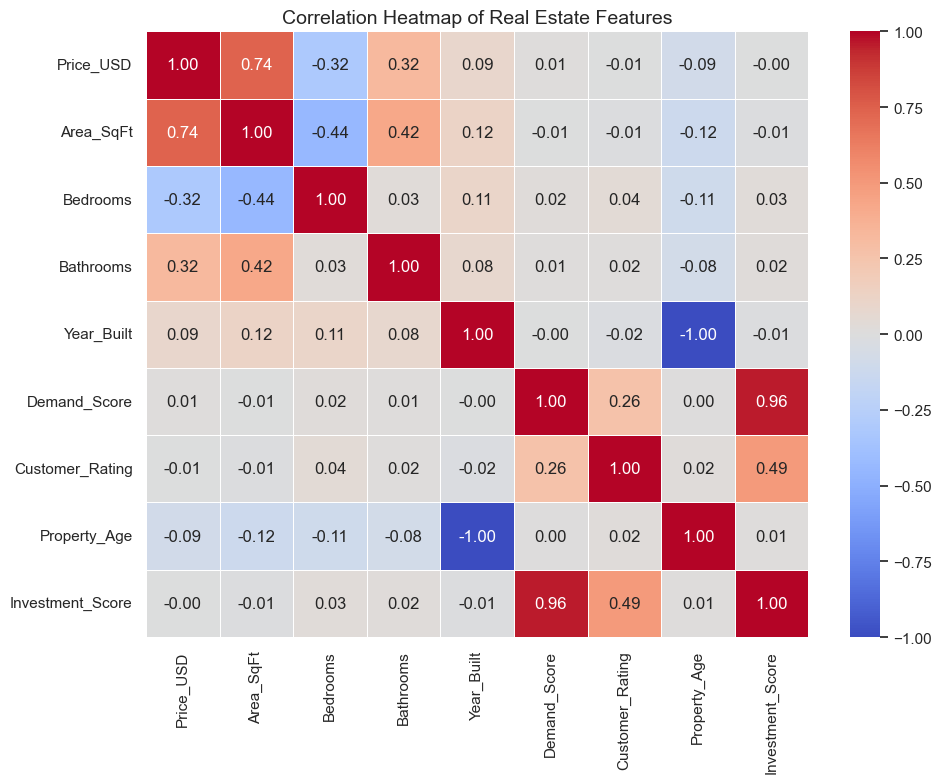

In [7]:
# Compute correlation matrix for numeric columns
numeric_cols = ['Price_USD', 'Area_SqFt', 'Bedrooms', 'Bathrooms', 'Year_Built', 'Demand_Score', 'Customer_Rating', 'Property_Age', 'Investment_Score']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Real Estate Features')
plt.tight_layout()
plt.savefig('../screenshots/eda_correlation.png', dpi=300)
plt.show()

### 5. Deep Dive into Investment Opportunity Scores

In [8]:
# Show top 5 localities for each city with highest investment opportunities
top_localities = df.groupby(['City', 'Locality'])['Investment_Score'].mean().reset_index()
top_localities = top_localities.sort_values(by='Investment_Score', ascending=False)
print("Top 10 overall localities with highest Investment Scores:")
print(top_localities.head(10).to_string(index=False))

Top 10 overall localities with highest Investment Scores:
         City     Locality  Investment_Score
     New York    Manhattan          6.925749
       Austin     Downtown          6.903067
San Francisco         SOMA          6.889503
        Miami  South Beach          6.868041
        Miami Coral Gables          6.269277
      Chicago  River North          6.260335
       Austin  East Austin          6.225405
     New York        Bronx          6.213483
     New York       Queens          6.177576
       Austin South Austin          6.160819


/var/folders/h0/tj8nz8m14mg2c5114wlv_3zh0000gq/T/ipykernel_11330/1432314678.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Property_Type', y='Investment_Score', inner='quartile', palette='Set2')


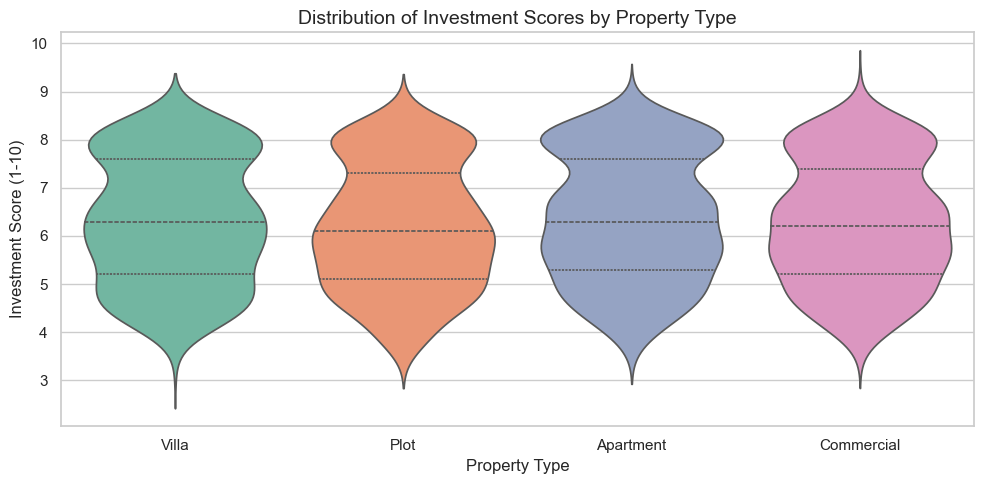

In [9]:
# Visualizing Investment Scores by Property Type
plt.figure(figsize=(10, 5))
sns.violinplot(data=df, x='Property_Type', y='Investment_Score', inner='quartile', palette='Set2')
plt.title('Distribution of Investment Scores by Property Type')
plt.ylabel('Investment Score (1-10)')
plt.xlabel('Property Type')
plt.tight_layout()
plt.savefig('../screenshots/investment_scores_by_type.png', dpi=300)
plt.show()